(309, 12)
Index(['release_year', 'album_type', 'album_name', 'track_name', 'bpm',
       'number_of_streams', 'total_time_played', 'total_time_played_h',
       'average_ms_played', 'average_ms_played_min', 'song_length_min',
       'avg_percent_song_played'],
      dtype='object')
Mean=87.395 Median=37.000 Mode=32.000
Variance=12120.571 Std=110.093
Q1=25.000 Q2=37.000 Q3=79.000 IQR=54.000
Number of outliers: 50


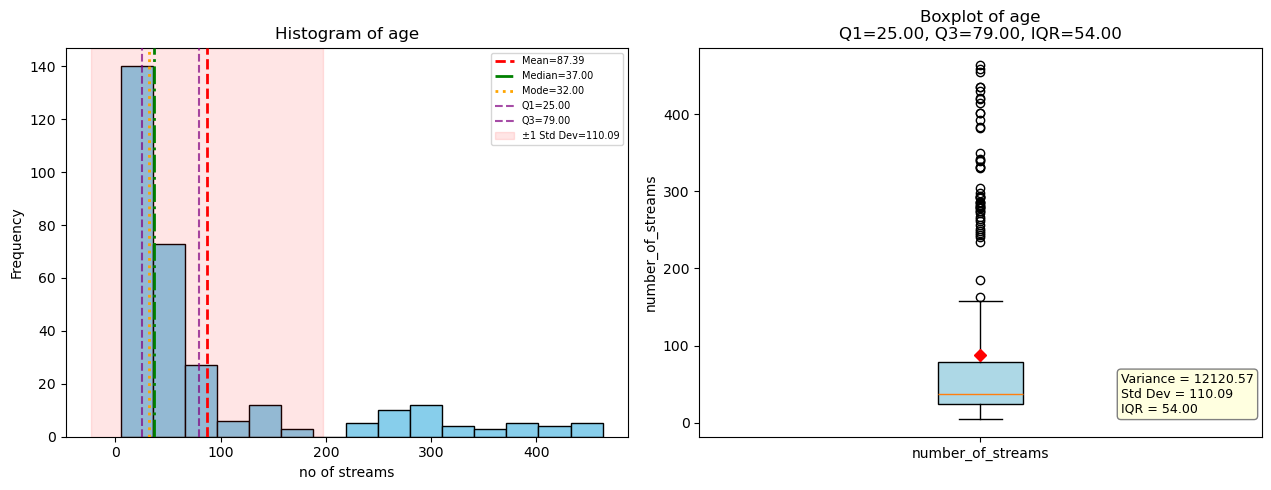

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load data
df = pd.read_csv("spotify_skz_counts_album.csv")
print(df.shape)
print(df.columns)

# 2. Select column
data = df["number_of_streams"].dropna()

# 3. Compute statistics
mean_val = data.mean()
median_val = data.median()
mode_val = data.mode()[0]
var_val = data.var()
std_val = data.std()
q1 = data.quantile(0.25)
q2 = data.quantile(0.50)
q3 = data.quantile(0.75)
iqr = q3 - q1

lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr
outliers = data[(data < lower_fence) | (data > upper_fence)]

print(f"Mean={mean_val:.3f} Median={median_val:.3f} Mode={mode_val:.3f}")
print(f"Variance={var_val:.3f} Std={std_val:.3f}")
print(f"Q1={q1:.3f} Q2={q2:.3f} Q3={q3:.3f} IQR={iqr:.3f}")
print(f"Number of outliers: {len(outliers)}")

# 4. Visualization
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ---- Histogram ----
axes[0].hist(data, bins=15, color="skyblue", edgecolor="black", zorder=1)
axes[0].axvline(mean_val, color="red", linestyle="--", linewidth=2, label=f"Mean={mean_val:.2f}", zorder=5)
axes[0].axvline(median_val, color="green", linestyle="-.", linewidth=2, label=f"Median={median_val:.2f}", zorder=5)
axes[0].axvline(mode_val, color="orange", linestyle=":", linewidth=2, label=f"Mode={mode_val:.2f}", zorder=5)
axes[0].axvline(q1, color="purple", linestyle="--", linewidth=1.5, alpha=0.7, label=f"Q1={q1:.2f}", zorder=4)
axes[0].axvline(q3, color="purple", linestyle="--", linewidth=1.5, alpha=0.7, label=f"Q3={q3:.2f}", zorder=4)
axes[0].axvspan(mean_val - std_val, mean_val + std_val, color="red", alpha=0.1, label=f"±1 Std Dev={std_val:.2f}")
axes[0].set_xlabel("no of streams")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Histogram of age")
axes[0].legend(fontsize=7)

# ---- Boxplot ----
axes[1].boxplot(data, vert=True, patch_artist=True, showmeans=True,
                 boxprops=dict(facecolor="lightblue"),
                 meanprops=dict(marker="D", markerfacecolor="red", markeredgecolor="red"))
axes[1].set_xticks([1])
axes[1].set_xticklabels(['number_of_streams'])
axes[1].set_ylabel("number_of_streams")
axes[1].set_title(f"Boxplot of age\nQ1={q1:.2f}, Q3={q3:.2f}, IQR={iqr:.2f}")

stats_text = f"Variance = {var_val:.2f}\nStd Dev = {std_val:.2f}\nIQR = {iqr:.2f}"
axes[1].text(1.25, median_val, stats_text, fontsize=9, va="center",
             bbox=dict(boxstyle="round", facecolor="lightyellow", edgecolor="gray"))

plt.tight_layout()
plt.show()